# Семинар 2 по РТЦиС

Задание 1 Разложение переодического радиоимпульса в дискретный ряд Фурье

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sg
from scipy.integrate import quad
pi = 3.1415
t = np.linspace(-10, 10, 1000)
w0=10

Существуют уже встроенные функции классических сигналов в блоке scipy

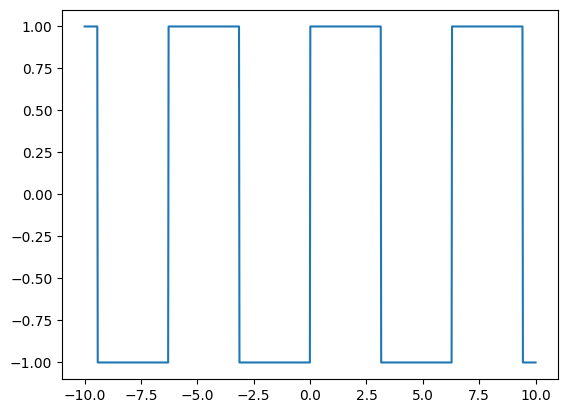

In [2]:
T=2*pi
freq=1/T
amp=1
def sp(t):
    return amp*sg.square(2*pi*freq*t, duty=0.5)
plt.plot(t,sp(t))

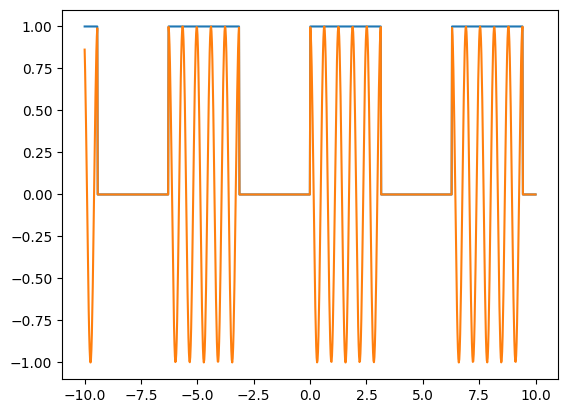

In [3]:
def spr(t):
    return np.piecewise(t, [sp(t) < 0, sp(t) >= 0], [0,1]) #Для сильного человека нет правил военной тактики.
plt.plot(t,spr(t))
def sr(t):
    return spr(t)
plt.plot(t,sr(t))

<StemContainer object of 3 artists>

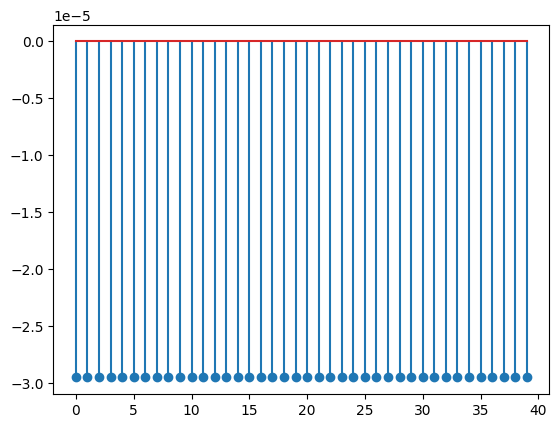

In [4]:
N=40

def integrandS(t, i):
    return sr(t)*np.sin(i*t)
#Функции это ХОРОШО. Без прямой зависимости от t интегрировать не будет!
ak=np.linspace(0, N, N)
ak=list(map(int,ak))
for i in range(N):
    ak[i]=(1/pi)*(quad(integrandS, -pi, pi, args=(i))[0]) #Сама по себе функция quad - кортеж, берем первый(нулевой) ее элемент
                                                          #Исчисление в Python начинается с 0!!!!!!!
                                                          #Аргумент - неизвестная при описании интеграла переменная
plt.stem(ak)


<StemContainer object of 3 artists>

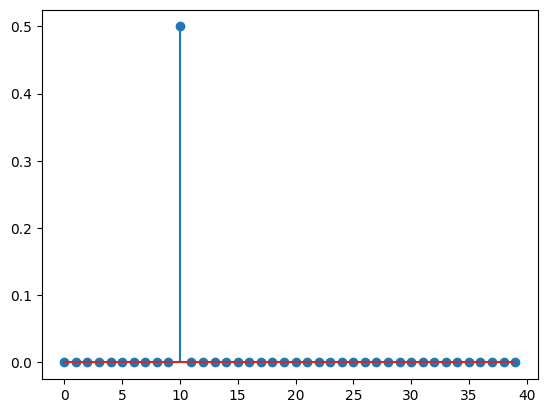

In [5]:
def integrandC(t, i):
    return sr(t)*np.cos(i*t)
bk=np.linspace(0, N, N)
bk=list(map(int,bk))
for i in range(N):
    bk[i]=(1/pi)*(quad(integrandC, -pi, pi, args=(i))[0])
plt.stem(bk)

In [6]:
Snew=0
for i in range(N):
    Snew=Snew+ak[i]*np.sin(i*t)+bk[i]*np.cos(i*t)

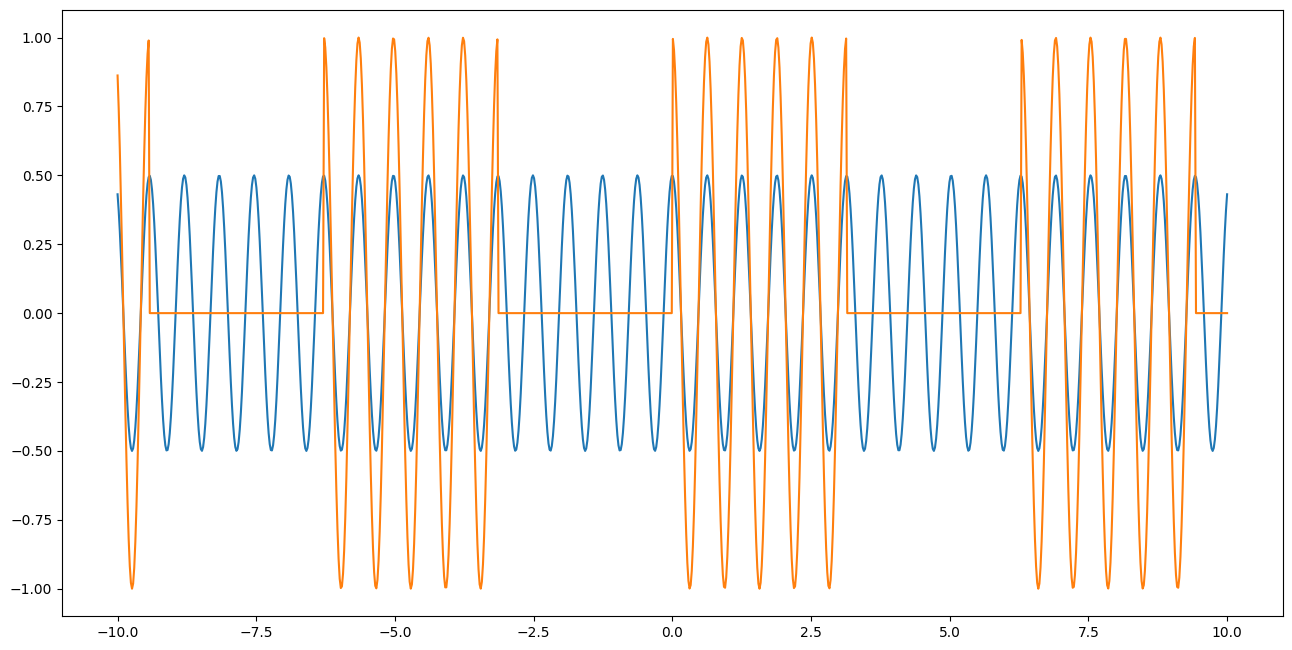

In [7]:
def cm_to_inch(value):
    return value/2.54
plt.figure(figsize=(cm_to_inch(40),cm_to_inch(20)))
plt.plot(t,Snew)
plt.plot(t,sr(t))